In [1]:
! pip install shap

In [2]:
import torch
from torchvision import transforms

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import os
import random

from PIL import Image
import numpy as np

## Load the data

In [3]:
data_dir = '/media/shadab/Others/Liver_Fibrosis_US_processed'

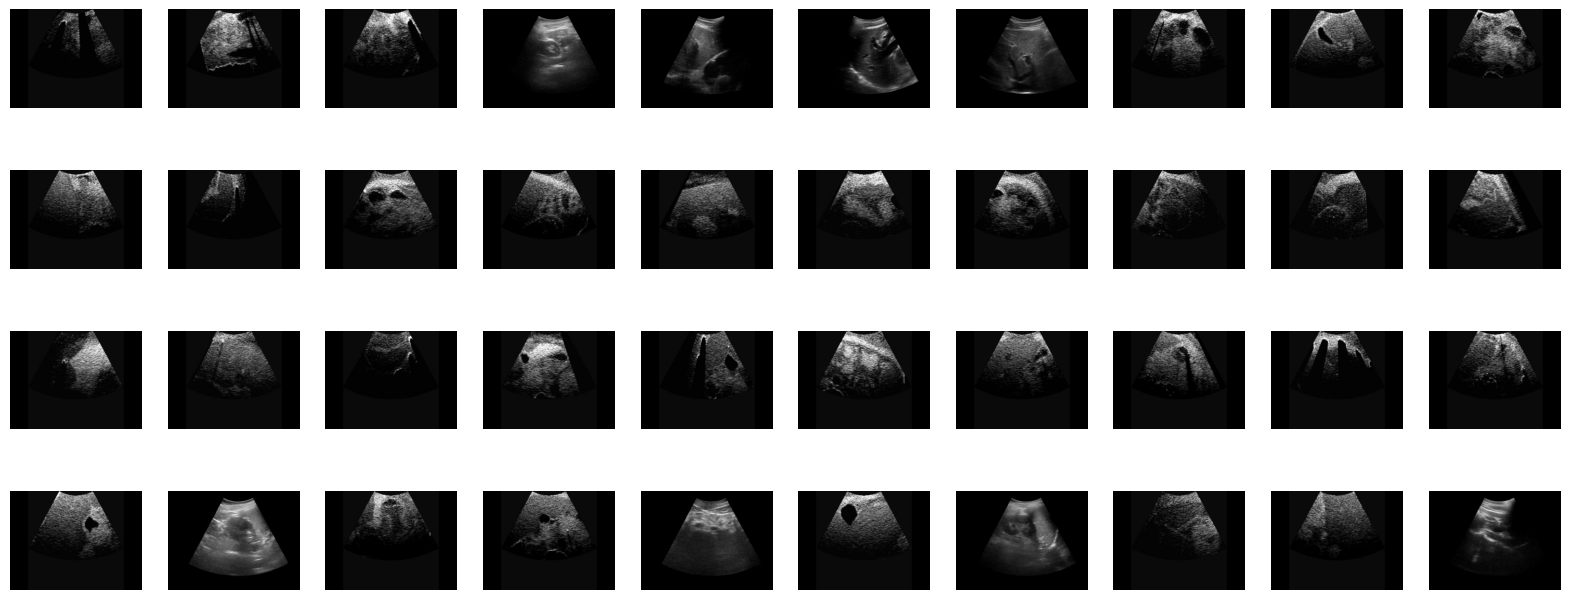

In [4]:
# Print 10 sample images from each class
classes = os.listdir(data_dir)


num_classes = len(classes)
fig, axes = plt.subplots(num_classes, 10, figsize=(20, 2 * num_classes))


for i, cls in enumerate(classes):
    cls_path = os.path.join(data_dir, cls)
    images = os.listdir(cls_path)[:10]
    for j, img_name in enumerate(images):
        img_path = os.path.join(cls_path, img_name)
        img = mpimg.imread(img_path)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
    axes[i, 0].set_ylabel(cls, size='large')

plt.show()

## Load the model

In [5]:
print("\n" + "="*80)
print("LOADING TRAINED MODELS")
print("="*80)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load DenseNet201 model for US images
densenet_model_path = '../Models/Ultrasound/Densenet201/densenet201_full_model.pt'
print(f"\nLoading DenseNet201 from: {densenet_model_path}")
densenet_model = torch.load(densenet_model_path, map_location=device, weights_only=False)
densenet_model.eval()
print("✅ DenseNet201 loaded successfully")


LOADING TRAINED MODELS
Using device: cpu

Loading DenseNet201 from: ../Models/Ultrasound/Densenet201/densenet201_full_model.pt
✅ DenseNet201 loaded successfully


In [6]:
print(densenet_model)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

## Get prediction from the model

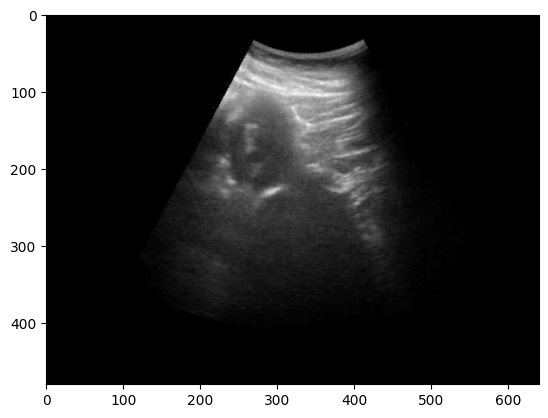

In [7]:
image = os.path.join(data_dir, 'F1', 'a13.jpg')


img = mpimg.imread(image)
plt.imshow(img, cmap='gray')

In [ ]:
# Convert to numpy array
arr = np.array(img)

# If grayscale, duplicate channels to make 3 channels
if arr.ndim == 2:
    arr = np.stack([arr, arr, arr], axis=-1)

# Discard the alpha channel if present
elif arr.shape[2] == 4:
    arr = arr[:, :, :3]

# Convert to float32 and scale to [0,1]
arr = arr.astype(np.float32)
if arr.max() > 1.0:
    arr /= 255.0


input_tensor = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(device)

# Inference
with torch.no_grad():
    output = densenet_model(input_tensor)
    pred = int(output.argmax(dim=1).item())

target = 0
target_name = classes[target]
pred_name = classes[pred]
print(f"Target: {target_name} ({target}) | Predicted: {pred_name} ({pred})")

Target: F1 (0) | Predicted: F1 (0)


: 

### Explain predictions with SHAP

In [ ]:
import shap
from PIL import Image
import numpy as np
import torch.nn as nn

# build a small background set (same size as the input image)
bg_paths = []
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    for fn in os.listdir(cls_path)[:10]:
        bg_paths.append(os.path.join(cls_path, fn))
        if len(bg_paths) >= 50:
            break
    if len(bg_paths) >= 50:
        break

bg_images = []
H, W = arr.shape[:2]
for p in bg_paths:
    im = Image.open(p).convert('RGB').resize((W, H))
    a = np.array(im).astype(np.float32)
    if a.max() > 1.0:
        a /= 255.0
    if a.ndim == 2:
        a = np.stack([a, a, a], axis=-1)
    bg_images.append(a)

bg_np = np.stack(bg_images, axis=0)
bg_tensor = torch.from_numpy(bg_np).permute(0, 3, 1, 2).to(device)

# Replace in-place ReLU with out-of-place to avoid view+inplace autograd errors
def replace_inplace_relu(module):
    for name, child in module.named_children():
        if isinstance(child, nn.ReLU) and getattr(child, 'inplace', False):
            setattr(module, name, nn.ReLU(inplace=False))
        else:
            replace_inplace_relu(child)

replace_inplace_relu(densenet_model)
densenet_model.to(device).eval()

# create DeepExplainer and compute SHAP values for the input image
try:
    explainer = shap.DeepExplainer(densenet_model, bg_tensor)
    shap_values = explainer.shap_values(input_tensor)
except RuntimeError as e:
    class _CloneOutputModel(nn.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m
        def forward(self, x):
            return self.m(x).clone()
    wrapped = _CloneOutputModel(densenet_model).to(device).eval()
    explainer = shap.DeepExplainer(wrapped, bg_tensor)
    shap_values = explainer.shap_values(input_tensor)

# prepare input for plotting: (1, H, W, 3)
input_pixels = input_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()

# display explanation
try:
    shap.image_plot(shap_values, np.array([input_pixels]))
except Exception as e:
    print('SHAP plotting failed:', e)